<a href="https://colab.research.google.com/github/lovnishverma/iris-demo/blob/main/iris_India_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab Notebooks: https://github.com/lovnishverma/Python-Getting-Started

**Outliers:** https://blog.devgenius.io/a-beginners-guide-to-detecting-and-handling-outliers-with-pizza-coffee-examples-243c3a2f1785

https://github.com/lovnishverma/Python-Getting-Started/blob/main/Handling_Outliers.ipynb

**PPT:** https://github.com/lovnishverma/Slidespptspdfs/blob/main/Machine%20Learning/Intro%20to%20Machine%20Learning.pdf

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv")

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [5]:
from sklearn.preprocessing import MinMaxScaler

scalar = MinMaxScaler()

df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']] = scalar.fit_transform(df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']])


df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,0.222222,0.625000,0.067797,0.041667,setosa
1,0.166667,0.416667,0.067797,0.041667,setosa
2,0.111111,0.500000,0.050847,0.041667,setosa
3,0.083333,0.458333,0.084746,0.041667,setosa
4,0.194444,0.666667,0.067797,0.041667,setosa
5,0.305556,0.791667,0.118644,0.125000,setosa
6,0.083333,0.583333,0.067797,0.083333,setosa
7,0.194444,0.583333,0.084746,0.041667,setosa
8,0.027778,0.375000,0.067797,0.041667,setosa
9,0.166667,0.458333,0.084746,0.000000,setosa


Understanding and Handling Imbalanced Datasets in Classification Models

https://blog.devgenius.io/understanding-and-handling-imbalanced-datasets-in-classification-models-bb10ac6fa1a7

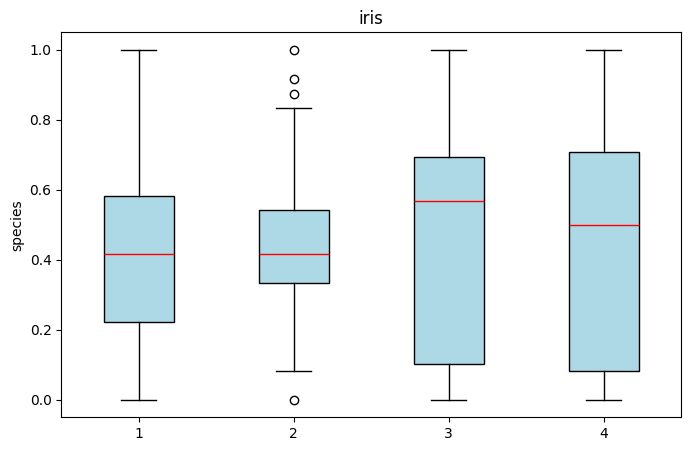

In [6]:
# box plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(x=df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']], patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red'))
plt.title("iris")
plt.ylabel("species")
plt.show()


In [7]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.439167,0.467571,0.457778
std,0.230018,0.180664,0.299054,0.317984
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


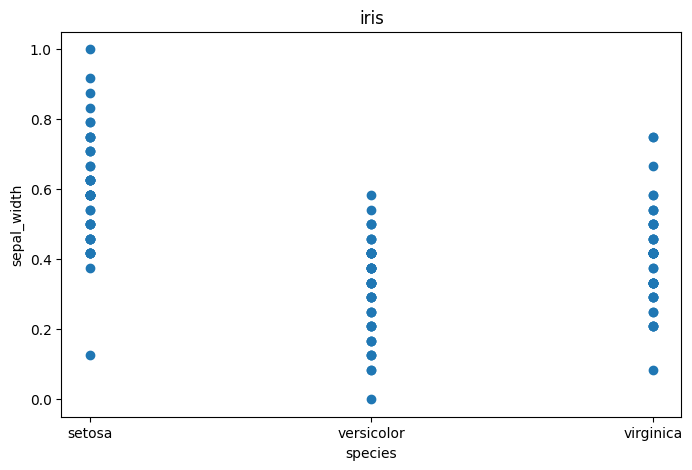

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(x=df['species'], y=df['sepal_width'])
plt.title("iris")
plt.ylabel("sepal_width")
plt.xlabel("species")
plt.show()


In [9]:
X = df[['sepal_length',	'sepal_width',	'petal_length', 'petal_width']] # features

y = df['species'] # Target

Class distribution in full dataset: Counter({'setosa': 50, 'versicolor': 50, 'virginica': 50})


/tmp/ipykernel_3889/351278052.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


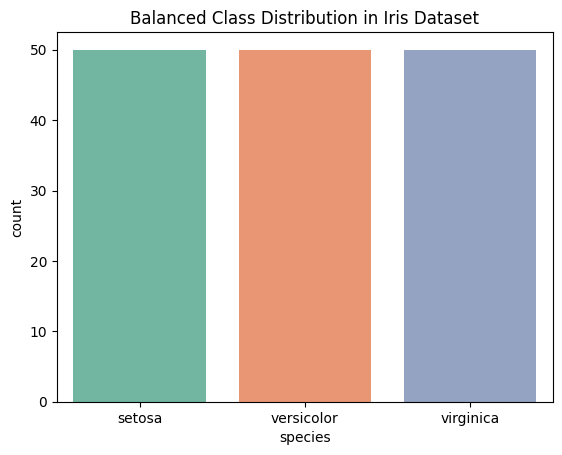

In [10]:
import seaborn as sns
from collections import Counter
print("Class distribution in full dataset:", Counter(y))
sns.countplot(x=y, palette="Set2")
plt.title("Balanced Class Distribution in Iris Dataset")
plt.show()

In [11]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667
146,0.555556,0.208333,0.677966,0.750000
147,0.611111,0.416667,0.711864,0.791667
148,0.527778,0.583333,0.745763,0.916667


In [12]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Without stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train distribution (no stratify):", Counter(y_train))
print("Train distribution (no stratify):", Counter(y_test))

Train distribution (no stratify): Counter({'versicolor': 41, 'setosa': 40, 'virginica': 39})
Train distribution (no stratify): Counter({'virginica': 11, 'setosa': 10, 'versicolor': 9})


In [13]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Without stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train distribution (no stratify):", Counter(y_train))
print("Train distribution (no stratify):", Counter(y_test))

Train distribution (no stratify): Counter({'setosa': 40, 'virginica': 40, 'versicolor': 40})
Train distribution (no stratify): Counter({'setosa': 10, 'virginica': 10, 'versicolor': 10})


In [14]:
X_train.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,120.000000,120.000000,120.000000,120.000000
mean,0.428241,0.435069,0.469633,0.460069
std,0.233591,0.185696,0.299562,0.318260
min,0.000000,0.000000,0.016949,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.402778,0.416667,0.550847,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [15]:
y_train.describe()

,species
count,120
unique,3
top,setosa
freq,40


In [16]:
X_test.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,30.000000,30.000000,30.000000,30.000000
mean,0.430556,0.455556,0.459322,0.448611
std,0.218935,0.160792,0.301963,0.322133
min,0.027778,0.125000,0.000000,0.041667
25%,0.263889,0.385417,0.093220,0.041667
50%,0.486111,0.416667,0.593220,0.541667
75%,0.611111,0.541667,0.690678,0.708333
max,0.833333,0.833333,0.898305,0.958333


In [17]:
y_test.describe()

,species
count,30
unique,3
top,setosa
freq,10


In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
 model = LogisticRegression()


model.fit(X_train, y_train)

LogisticRegression()

In [20]:
X_test.head(3)

,sepal_length,sepal_width,petal_length,petal_width
38,0.027778,0.416667,0.050847,0.041667
127,0.500000,0.416667,0.661017,0.708333
57,0.166667,0.166667,0.389831,0.375000


In [21]:
y_test.head()

,species
38,setosa
127,virginica
57,versicolor
93,versicolor
42,setosa


In [22]:
# Model evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



https://www.w3schools.com/python/python_ml_confusion_matrix.asp

In [24]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]


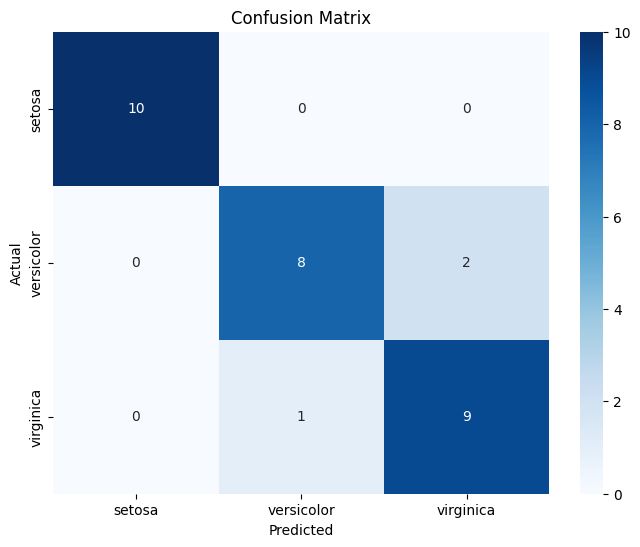

In [25]:
# confusion_matrix using matpotlib with proper labels and title

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig("confusion_matrix_plot.png")
plt.show()

In [26]:
# test on unseen input

prediction = model.predict([[6.7,3.5,5.3,2.5]])


print(prediction[0])

virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [27]:
# taking input from user

sepal_length = float(input("Enter sepal_length: "))
sepal_width = float(input("Enter sepal_width: "))
petal_length = float(input("Enter petal_length: "))
petal_width = float(input("Enter petal_width: "))

prediction = model.predict([[sepal_length, sepal_width, petal_length, petal_width]])

print(prediction[0])

Enter sepal_length: 1
Enter sepal_width: 1
Enter petal_length: 1
Enter petal_width: 1
virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [1]:
import joblib

# save model

joblib.dump(model, "model.joblib")

NameError: name 'model' is not defined

In [31]:
# save scalar

joblib.dump(scalar, "scalar.joblib")

['scalar.joblib']

In [2]:
# load model

loaded_model = joblib.load("model.joblib")

# load scalar
joblib.load("scalar.joblib")

MinMaxScaler()

In [3]:

prediction = loaded_model .predict([[6.7,3.5,5.3,2.5]])


print(prediction[0])

virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
